# Evaluate Delphi Model AUC for Death Prediction

This notebook evaluates the Area Under the ROC Curve (AUC) of the Delphi model specifically for predicting death events.

**Key Features:**
- Loads a trained Delphi model checkpoint
- Evaluates on validation data
- Computes AUC stratified by age groups and sex
- Uses DeLong's method for confidence intervals
- Visualizes results with detailed plots


In [1]:
# =============================================================================
# Imports and Setup
# =============================================================================
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

# Add parent directory to path for imports
sys.path.insert(0, '.')

from model import DelphiConfig, Delphi
from utils import get_batch, get_p2i

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.3.0+cu121
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


## Configuration

Set up paths to your model checkpoint and data files.


In [ ]:
# =============================================================================
# CONFIGURATION - Modify these settings for your setup
# =============================================================================

# Model checkpoint path
model_ckpt_path = 'Delphi-2M-respiratory/ckpt.pt'  # Path to trained model checkpoint

# Data paths
data_dir = 'data/ukb_respiratory_data'  # Directory containing train.bin and val.bin

# Labels file (contains ICD-10 code mapping and chapter info)
labels_file = 'delphi_labels_chapters_colours_icd.csv'

# Output directory for results
output_dir = 'evaluation_results/death_auc'

# Death label index (from delphi_labels_chapters_colours_icd.csv)
DEATH_LABEL_INDEX = 1268

# Evaluation parameters
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 128          # Batch size for model inference
block_size = 80           # Sequence length for input
no_event_token_rate = 5   # Rate for "no event" token insertion
dataset_subset_size = -1  # -1 for full dataset, or set a number for debugging

# Age groups for stratified analysis (in years)
age_groups = np.arange(40, 85, 5)  # 40-44, 45-49, ..., 80-84

# Prediction offset (time before event to make prediction, in days)
# 365.25 = 1 year before death
prediction_offset = 365.25

# Random seed for reproducibility
seed = 1337

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Model checkpoint: {model_ckpt_path}")
print(f"  Data directory: {data_dir}")
print(f"  Device: {device}")
print(f"  Prediction offset: {prediction_offset/365.25:.1f} years before event")
print(f"  Age groups: {age_groups[0]}-{age_groups[-1]+4} years")


Configuration:
  Model checkpoint: Delphi-2M-respiratory/ckpt.pt
  Data directory: data/ukb_respiratory_data
  Device: cuda
  Prediction offset: 1.0 years before event
  Age groups: 40-84 years


## Load Model and Data


In [3]:
# =============================================================================
# Load Model
# =============================================================================
print("Loading model...")

# Set random seeds
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)

# Load checkpoint
checkpoint = torch.load(model_ckpt_path, map_location=device)
print(f"  Checkpoint keys: {checkpoint.keys()}")

# Initialize model from checkpoint config
model_args = checkpoint['model_args']
print(f"  Model args: {model_args}")

config = DelphiConfig(**model_args)
model = Delphi(config)

# Load weights
state_dict = checkpoint['model']
model.load_state_dict(state_dict)
model.eval()
model = model.to(device)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"  Model loaded with {n_params/1e6:.2f}M parameters")
print(f"  Model on device: {next(model.parameters()).device}")


Loading model...
  Checkpoint keys: dict_keys(['model', 'optimizer', 'model_args', 'iter_num', 'best_val_loss', 'config'])
  Model args: {'n_layer': 12, 'n_head': 12, 'n_embd': 120, 'block_size': 48, 'bias': False, 'vocab_size': 1270, 'dropout': 0.1, 'token_dropout': 0.0, 't_min': 0.1, 'mask_ties': True, 'ignore_tokens': [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}
number of parameters: 2.24M
  Model loaded with 2.24M parameters
  Model on device: cuda:0


In [4]:
# =============================================================================
# Load Validation Data
# =============================================================================
print("Loading validation data...")

# Load binary data
val_path = f"{data_dir}/val.bin"
val = np.fromfile(val_path, dtype=np.uint32).reshape(-1, 3).astype(np.int64)

# Get patient to index mapping
val_p2i = get_p2i(val)

print(f"  Validation data shape: {val.shape}")
print(f"  Number of patients: {len(val_p2i)}")
print(f"  Data columns: [patient_id, days_from_birth, label_index]")

# Check for death events in the data
death_events = val[val[:, 2] == DEATH_LABEL_INDEX]
print(f"\n  Death events found: {len(death_events)}")
if len(death_events) > 0:
    print(f"  Sample death events: {death_events[:5]}")

# Load labels for display
delphi_labels = pd.read_csv(labels_file)
death_label_row = delphi_labels[delphi_labels['index'] == DEATH_LABEL_INDEX]
print(f"\n  Death label info:")
print(death_label_row.to_string(index=False))


Loading validation data...
  Validation data shape: (556534, 3)
  Number of patients: 26769
  Data columns: [patient_id, days_from_birth, label_index]

  Death events found: 6996
  Sample death events: [[5024954   30301    1268]
 [5025046   24171    1268]
 [5025072   28439    1268]
 [5025095   28586    1268]
 [5025137   26660    1268]]

  Death label info:
 index                    name  count                               ICD-10 Chapter     ICD-10 Chapter (short)   color
  1268 O01 Hydatidiform mole38   26.0 XV. Pregnancy, childbirth and the puerperium XV. Pregnancy & Childbirth #e377c2


In [26]:
print(len(val[val[:, 2] == 4]))
print(len(np.unique(val[:,0])))

12183
26769


## AUC Calculation Functions

These functions compute AUC with confidence intervals using DeLong's method.


In [6]:
# =============================================================================
# AUC Calculation Functions (from evaluate_auc.py)
# =============================================================================

def compute_midrank(x):
    """Computes midranks for DeLong's method."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=np.float32)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=np.float32)
    T2[J] = T + 1
    return T2


def fastDeLong(predictions_sorted_transposed, label_1_count):
    """
    Fast DeLong's method for computing AUC covariance.
    Reference: Sun & Xu, IEEE Signal Processing Letters, 2014
    """
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=np.float32)
    ty = np.empty([k, n], dtype=np.float32)
    tz = np.empty([k, m + n], dtype=np.float32)
    
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov


def get_auc_delong_var(healthy_scores, diseased_scores):
    """
    Computes ROC AUC value and variance using DeLong's method.
    
    Args:
        healthy_scores: Prediction scores for controls (no death)
        diseased_scores: Prediction scores for cases (death)
    
    Returns:
        AUC value and variance
    """
    ground_truth = np.array([1] * len(diseased_scores) + [0] * len(healthy_scores))
    predictions = np.concatenate([diseased_scores, healthy_scores])
    
    order = (-ground_truth).argsort()
    label_1_count = int(ground_truth.sum())
    predictions_sorted_transposed = predictions[np.newaxis, order]
    
    aucs, delongcov = fastDeLong(predictions_sorted_transposed, label_1_count)
    
    return aucs[0], delongcov


def simple_auc(case_scores, control_scores):
    """Simple AUC calculation using Mann-Whitney U statistic."""
    n1 = len(case_scores)
    n2 = len(control_scores)
    if n1 == 0 or n2 == 0:
        return np.nan
    R1 = np.concatenate([case_scores, control_scores]).argsort().argsort()[:n1].sum() + n1
    U1 = n1 * n2 + 0.5 * n1 * (n1 + 1) - R1
    return U1 / n1 / n2


print("AUC calculation functions loaded.")


AUC calculation functions loaded.


## Prepare Data for Evaluation

Get batched data and run model inference.


In [7]:
# =============================================================================
# Prepare Evaluation Data
# =============================================================================

# Determine dataset size
if dataset_subset_size == -1:
    dataset_subset_size = len(val_p2i)
else:
    dataset_subset_size = min(dataset_subset_size, len(val_p2i))

print(f"Evaluating on {dataset_subset_size} patients...")

# Get batched data for evaluation
d_eval = get_batch(
    range(dataset_subset_size),
    val,
    val_p2i,
    select='left',
    block_size=block_size,
    device=device,
    padding='random',
    no_event_token_rate=no_event_token_rate,
)

print(f"\nBatch data shapes:")
print(f"  Input tokens (x): {d_eval[0].shape}")
print(f"  Input ages (a): {d_eval[1].shape}")
print(f"  Target tokens (y): {d_eval[2].shape}")
print(f"  Target ages (b): {d_eval[3].shape}")


Evaluating on 26769 patients...

Batch data shapes:
  Input tokens (x): torch.Size([26769, 80])
  Input ages (a): torch.Size([26769, 80])
  Target tokens (y): torch.Size([26769, 80])
  Target ages (b): torch.Size([26769, 80])


In [8]:
# =============================================================================
# Run Model Inference
# =============================================================================
print("Running model inference...")

# Store predictions for the death label only
death_predictions = []

model.to(device)
with torch.no_grad():
    # Process in batches
    n_batches = (d_eval[0].shape[0] + batch_size - 1) // batch_size
    
    for i, batch_data in tqdm(
        enumerate(zip(*[torch.split(x, batch_size) for x in d_eval])),
        total=n_batches,
        desc="Model inference"
    ):
        batch_data = [x.to(device) for x in batch_data]
        
        # Get model outputs (logits)
        outputs = model(batch_data[0], batch_data[1])[0]
        
        # Extract only the death prediction column
        death_logits = outputs[:, :, DEATH_LABEL_INDEX].cpu().detach().numpy()
        death_predictions.append(death_logits)

# Stack all predictions
death_predictions = np.vstack(death_predictions)
print(f"\nDeath predictions shape: {death_predictions.shape}")
print(f"  (patients x sequence_positions)")


Running model inference...


Model inference: 100%|██████████| 210/210 [00:02<00:00, 94.75it/s] 


Death predictions shape: (26769, 80)
  (patients x sequence_positions)


## Compute Death AUC by Age Group and Sex

Calculate AUC for death prediction stratified by age groups and sex.


In [ ]:
# =============================================================================
# Compute AUC for Death Prediction
# =============================================================================

def compute_death_auc(d_eval, death_predictions, death_label_idx, offset, age_groups):
    """
    Compute AUC for death prediction stratified by age groups and sex.
    
    Args:
        d_eval: Tuple of (x, a, y, b) tensors from get_batch
        death_predictions: Model predictions for death label
        death_label_idx: Index of death label
        offset: Time before death to make prediction (days)
        age_groups: Array of age group starts
    
    Returns:
        DataFrame with AUC results
    """
    # Convert to numpy
    x, a, y, b = [t.cpu().numpy() if torch.is_tensor(t) else t for t in d_eval]
    
    age_step = age_groups[1] - age_groups[0]
    results = []
    
    # Find indices where target is death
    # y contains tokens shifted by 1 (so actual label = y - 1)
    death_cases_mask = (y == death_label_idx + 1)  # +1 because tokens are shifted
    
    # Precompute prediction indices: for each target, find the last valid input position
    # that is at least 'offset' days before the target time
    pred_idx = (a[:, :, np.newaxis] <= b[:, np.newaxis, :] - offset).sum(1) - 1
    
    # Process by sex
    # IMPORTANT: Token indices match the actual label indices in the binary data
    # The preprocessing uses labels.csv where: Female=label 1, Male=label 2
    # In the binary data, these are stored directly as label indices (no +1 shift)
    # So: Female=1, Male=2 in the data
    # But when used as tokens in sequences, they appear as: Female=2, Male=3
    # (This is because Padding=-1, No event=0, so Female=1 becomes token 2, Male=2 becomes token 3)
    FEMALE_TOKEN = 2  # label 1 -> token 2 (corrected from 3)
    MALE_TOKEN = 3    # label 2 -> token 3 (corrected from 4)
    
    for sex_name, sex_token in [("female", FEMALE_TOKEN), ("male", MALE_TOKEN)]:
        # Find patients of this sex (sex token appears somewhere in their sequence)
        sex_mask = (x == sex_token).any(axis=1)
        
        if sex_mask.sum() == 0:
            print(f"Warning: No {sex_name} patients found")
            continue
        
        # Get death cases and controls for this sex
        death_case_indices = np.where(sex_mask[:, np.newaxis] & death_cases_mask)
        
        # For controls: patients without death event
        control_mask = sex_mask & ~death_cases_mask.any(axis=1)
        control_indices = np.where(control_mask[:, np.newaxis] & np.ones_like(y, dtype=bool))
        
        print(f"\n{sex_name.capitalize()}:")
        print(f"  Death cases: {len(np.unique(death_case_indices[0]))}")
        print(f"  Controls: {len(np.unique(control_indices[0]))}")
        
        for age_start in age_groups:
            age_end = age_start + age_step
            
            # Get cases in this age group
            # Age is in days, age_groups are in years
            case_mask_age = (
                (a[death_case_indices] / 365.25 >= age_start) & 
                (a[death_case_indices] / 365.25 < age_end)
            )
            
            control_mask_age = (
                (a[control_indices] / 365.25 >= age_start) & 
                (a[control_indices] / 365.25 < age_end)
            )
            
            # Get prediction scores
            case_patient_idx = death_case_indices[0][case_mask_age]
            case_seq_idx = death_case_indices[1][case_mask_age]
            
            control_patient_idx = control_indices[0][control_mask_age]
            control_seq_idx = control_indices[1][control_mask_age]
            
            # Use the prediction index (position before offset)
            case_pred_idx = pred_idx[case_patient_idx, case_seq_idx]
            control_pred_idx = pred_idx[control_patient_idx, control_seq_idx]
            
            # Filter valid prediction indices
            valid_case = case_pred_idx >= 0
            valid_control = control_pred_idx >= 0
            
            case_scores = death_predictions[
                case_patient_idx[valid_case], 
                case_pred_idx[valid_case]
            ]
            control_scores = death_predictions[
                control_patient_idx[valid_control], 
                control_pred_idx[valid_control]
            ]
            
            # Deduplicate by patient (take one sample per patient)
            if len(case_scores) > 0:
                _, unique_idx = np.unique(case_patient_idx[valid_case], return_index=True)
                case_scores = case_scores[unique_idx]
            
            if len(control_scores) > 0:
                _, unique_idx = np.unique(control_patient_idx[valid_control], return_index=True)
                control_scores = control_scores[unique_idx]
            
            if len(case_scores) < 2 or len(control_scores) < 2:
                continue
            
            # Compute AUC with DeLong variance
            try:
                auc_value, auc_var = get_auc_delong_var(control_scores, case_scores)
                auc_std = np.sqrt(auc_var) if auc_var > 0 else 0
                
                results.append({
                    'sex': sex_name,
                    'age_group': f"{age_start}-{age_end-1}",
                    'age_start': age_start,
                    'auc': auc_value,
                    'auc_std': auc_std,
                    'auc_ci_lower': auc_value - 1.96 * auc_std,
                    'auc_ci_upper': auc_value + 1.96 * auc_std,
                    'n_cases': len(case_scores),
                    'n_controls': len(control_scores),
                })
            except Exception as e:
                print(f"  Error computing AUC for {sex_name}, age {age_start}: {e}")
    
    return pd.DataFrame(results)


# Run the AUC computation
print("Computing death AUC by age group and sex...")
auc_results = compute_death_auc(
    d_eval, 
    death_predictions, 
    DEATH_LABEL_INDEX, 
    prediction_offset, 
    age_groups
)

print(f"\n\nResults computed for {len(auc_results)} age-sex combinations")


Computing death AUC by age group and sex...

Female:
  Death cases: 4069
  Controls: 9120

Male:
  Death cases: 620
  Controls: 1487


Results computed for 18 age-sex combinations


## Display Results


In [10]:
# =============================================================================
# Display Results Table
# =============================================================================

if len(auc_results) > 0:
    print("=" * 80)
    print("DEATH PREDICTION AUC RESULTS")
    print("=" * 80)
    print(f"\nPrediction offset: {prediction_offset/365.25:.1f} years before death")
    
    # Display full results table
    display_cols = ['sex', 'age_group', 'auc', 'auc_ci_lower', 'auc_ci_upper', 'n_cases', 'n_controls']
    print("\nDetailed Results by Age Group and Sex:")
    print("-" * 80)
    
    for sex in ['female', 'male']:
        sex_data = auc_results[auc_results['sex'] == sex]
        if len(sex_data) > 0:
            print(f"\n{sex.upper()}:")
            for _, row in sex_data.iterrows():
                print(f"  Age {row['age_group']}: AUC = {row['auc']:.3f} "
                      f"(95% CI: {row['auc_ci_lower']:.3f}-{row['auc_ci_upper']:.3f}), "
                      f"n_cases={row['n_cases']}, n_controls={row['n_controls']}")
    
    # Compute overall AUC (pooled across age groups)
    print("\n" + "=" * 80)
    print("SUMMARY STATISTICS")
    print("=" * 80)
    
    for sex in ['female', 'male']:
        sex_data = auc_results[auc_results['sex'] == sex]
        if len(sex_data) > 0:
            mean_auc = sex_data['auc'].mean()
            # Pooled variance (combining DeLong variances)
            pooled_var = (sex_data['auc_std']**2).sum() / (len(sex_data)**2)
            pooled_std = np.sqrt(pooled_var)
            total_cases = sex_data['n_cases'].sum()
            total_controls = sex_data['n_controls'].sum()
            
            print(f"\n{sex.upper()} (pooled across age groups):")
            print(f"  Mean AUC: {mean_auc:.3f} ± {pooled_std:.3f}")
            print(f"  Total cases: {total_cases}")
            print(f"  Total controls: {total_controls}")
    
    # Overall (both sexes)
    overall_auc = auc_results['auc'].mean()
    print(f"\nOVERALL Mean AUC: {overall_auc:.3f}")
else:
    print("No AUC results computed. Check if death events exist in the data.")


DEATH PREDICTION AUC RESULTS

Prediction offset: 1.0 years before death

Detailed Results by Age Group and Sex:
--------------------------------------------------------------------------------

FEMALE:
  Age 40-44: AUC = 0.845 (95% CI: 0.729-0.962), n_cases=4, n_controls=6719
  Age 45-49: AUC = 0.358 (95% CI: 0.234-0.482), n_cases=25, n_controls=7021
  Age 50-54: AUC = 0.358 (95% CI: 0.280-0.437), n_cases=74, n_controls=7215
  Age 55-59: AUC = 0.354 (95% CI: 0.307-0.401), n_cases=162, n_controls=6910
  Age 60-64: AUC = 0.310 (95% CI: 0.278-0.342), n_cases=317, n_controls=6265
  Age 65-69: AUC = 0.312 (95% CI: 0.291-0.334), n_cases=687, n_controls=5319
  Age 70-74: AUC = 0.320 (95% CI: 0.301-0.339), n_cases=1106, n_controls=3917
  Age 75-79: AUC = 0.312 (95% CI: 0.292-0.332), n_cases=1104, n_controls=2173
  Age 80-84: AUC = 0.274 (95% CI: 0.244-0.303), n_cases=576, n_controls=519

MALE:
  Age 40-44: AUC = 0.178 (95% CI: 0.155-0.201), n_cases=2, n_controls=1126
  Age 45-49: AUC = 0.049 (

## Visualizations


Figure saved to: evaluation_results/death_auc/death_auc_by_age_sex.png


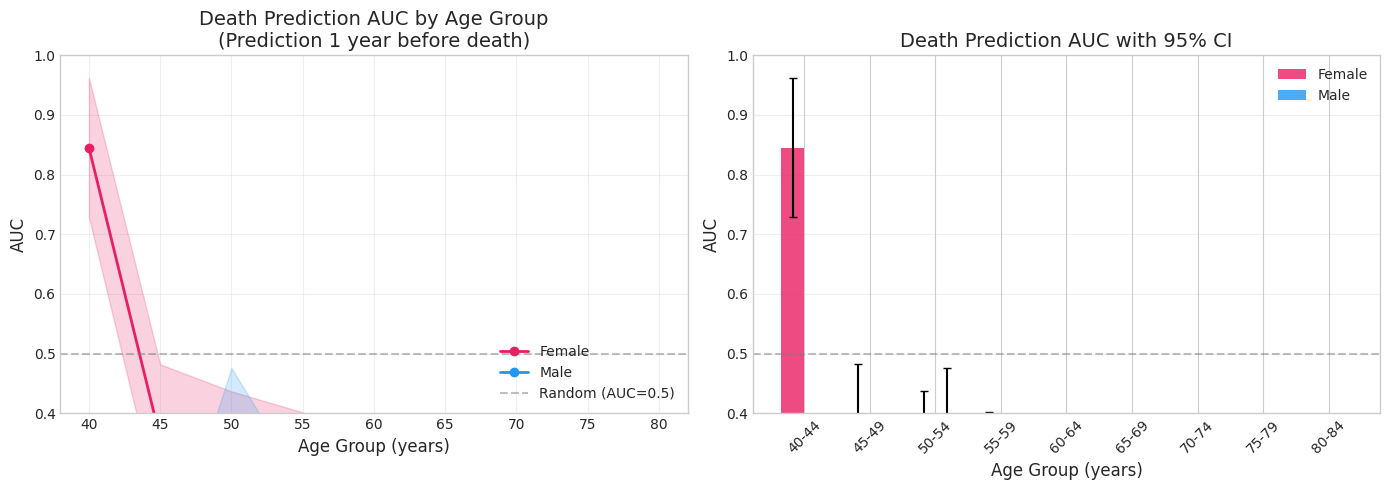

In [11]:
# =============================================================================
# Visualization: AUC by Age Group and Sex
# =============================================================================

if len(auc_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Line plot with confidence intervals
    ax1 = axes[0]
    colors = {'female': '#E91E63', 'male': '#2196F3'}
    
    for sex in ['female', 'male']:
        sex_data = auc_results[auc_results['sex'] == sex].sort_values('age_start')
        if len(sex_data) > 0:
            ax1.plot(sex_data['age_start'], sex_data['auc'], 
                    marker='o', linewidth=2, label=sex.capitalize(),
                    color=colors[sex])
            ax1.fill_between(sex_data['age_start'], 
                            sex_data['auc_ci_lower'], 
                            sex_data['auc_ci_upper'],
                            alpha=0.2, color=colors[sex])
    
    ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (AUC=0.5)')
    ax1.set_xlabel('Age Group (years)', fontsize=12)
    ax1.set_ylabel('AUC', fontsize=12)
    ax1.set_title(f'Death Prediction AUC by Age Group\n(Prediction {prediction_offset/365.25:.0f} year before death)', 
                  fontsize=14)
    ax1.legend(loc='lower right')
    ax1.set_ylim(0.4, 1.0)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Bar plot with error bars
    ax2 = axes[1]
    
    x = np.arange(len(age_groups))
    width = 0.35
    
    female_data = auc_results[auc_results['sex'] == 'female'].sort_values('age_start')
    male_data = auc_results[auc_results['sex'] == 'male'].sort_values('age_start')
    
    if len(female_data) > 0:
        ax2.bar(x - width/2, female_data['auc'], width, 
               yerr=1.96 * female_data['auc_std'],
               label='Female', color=colors['female'], alpha=0.8,
               capsize=3)
    
    if len(male_data) > 0:
        ax2.bar(x + width/2, male_data['auc'], width,
               yerr=1.96 * male_data['auc_std'],
               label='Male', color=colors['male'], alpha=0.8,
               capsize=3)
    
    ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Age Group (years)', fontsize=12)
    ax2.set_ylabel('AUC', fontsize=12)
    ax2.set_title('Death Prediction AUC with 95% CI', fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"{a}-{a+4}" for a in age_groups], rotation=45)
    ax2.legend()
    ax2.set_ylim(0.4, 1.0)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Save figure
    fig_path = f"{output_dir}/death_auc_by_age_sex.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Figure saved to: {fig_path}")
    
    plt.show()
else:
    print("No results to visualize.")


Figure saved to: evaluation_results/death_auc/death_sample_size_distribution.png


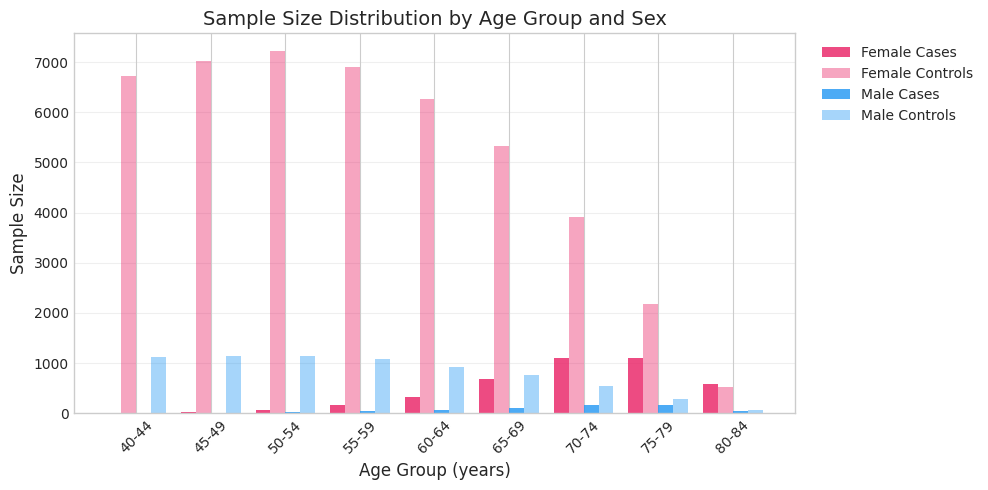

In [12]:
# =============================================================================
# Visualization: Sample Size Distribution
# =============================================================================

if len(auc_results) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x = np.arange(len(age_groups))
    width = 0.2
    
    female_data = auc_results[auc_results['sex'] == 'female'].sort_values('age_start')
    male_data = auc_results[auc_results['sex'] == 'male'].sort_values('age_start')
    
    # Plot case counts
    if len(female_data) > 0:
        ax.bar(x - width*1.5, female_data['n_cases'], width, 
               label='Female Cases', color='#E91E63', alpha=0.8)
        ax.bar(x - width*0.5, female_data['n_controls'], width, 
               label='Female Controls', color='#E91E63', alpha=0.4)
    
    if len(male_data) > 0:
        ax.bar(x + width*0.5, male_data['n_cases'], width, 
               label='Male Cases', color='#2196F3', alpha=0.8)
        ax.bar(x + width*1.5, male_data['n_controls'], width, 
               label='Male Controls', color='#2196F3', alpha=0.4)
    
    ax.set_xlabel('Age Group (years)', fontsize=12)
    ax.set_ylabel('Sample Size', fontsize=12)
    ax.set_title('Sample Size Distribution by Age Group and Sex', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{a}-{a+4}" for a in age_groups], rotation=45)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Save figure
    fig_path = f"{output_dir}/death_sample_size_distribution.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Figure saved to: {fig_path}")
    
    plt.show()


## Save Results


In [13]:
# =============================================================================
# Save Results to Files
# =============================================================================

if len(auc_results) > 0:
    # Save detailed results
    results_path = f"{output_dir}/death_auc_results.csv"
    auc_results.to_csv(results_path, index=False)
    print(f"Detailed results saved to: {results_path}")
    
    # Save summary statistics
    summary_data = []
    for sex in ['female', 'male']:
        sex_data = auc_results[auc_results['sex'] == sex]
        if len(sex_data) > 0:
            summary_data.append({
                'sex': sex,
                'mean_auc': sex_data['auc'].mean(),
                'std_auc': sex_data['auc'].std(),
                'min_auc': sex_data['auc'].min(),
                'max_auc': sex_data['auc'].max(),
                'total_cases': sex_data['n_cases'].sum(),
                'total_controls': sex_data['n_controls'].sum(),
                'n_age_groups': len(sex_data),
            })
    
    # Overall
    summary_data.append({
        'sex': 'overall',
        'mean_auc': auc_results['auc'].mean(),
        'std_auc': auc_results['auc'].std(),
        'min_auc': auc_results['auc'].min(),
        'max_auc': auc_results['auc'].max(),
        'total_cases': auc_results['n_cases'].sum(),
        'total_controls': auc_results['n_controls'].sum(),
        'n_age_groups': len(auc_results),
    })
    
    summary_df = pd.DataFrame(summary_data)
    summary_path = f"{output_dir}/death_auc_summary.csv"
    summary_df.to_csv(summary_path, index=False)
    print(f"Summary statistics saved to: {summary_path}")
    
    # Display summary
    print("\n" + "=" * 80)
    print("FINAL SUMMARY")
    print("=" * 80)
    print(summary_df.to_string(index=False))
    
    print(f"\n\nAll results saved to: {output_dir}/")
else:
    print("No results to save.")


Detailed results saved to: evaluation_results/death_auc/death_auc_results.csv
Summary statistics saved to: evaluation_results/death_auc/death_auc_summary.csv

FINAL SUMMARY
    sex  mean_auc  std_auc  min_auc  max_auc  total_cases  total_controls  n_age_groups
 female  0.382648 0.175784 0.273519 0.845401         4055           46058             9
   male  0.214068 0.082428 0.049388 0.338730          619            7052             9
overall  0.298358 0.158938 0.049388 0.845401         4674           53110            18


All results saved to: evaluation_results/death_auc/
